## 1. Target exploration

Track A predicts seven simulator parameters:
planetary radius, atmospheric
temperature and five molecular log-abundances. Their order is defined
explicitly because every later target array, model output and inverse
transformation must use the same order.

This section verifies that all required targets exist and contain finite numeric
values. It then summarises their distributions and numerical scales. These are
source-data EDA statistics only(!), they will not be used as fitted preprocessing
parameters.

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_PATH = (
    PROJECT_ROOT
    / "FullDataset"
    / "TrainingData"
    / "Ground Truth Package"
    / "FM_Parameter_Table.csv"
)

if not TARGET_PATH.is_file():
    raise FileNotFoundError(
        f"Simulator target table not found: {TARGET_PATH}"
    )

targets = pd.read_csv(TARGET_PATH)

print("Target file:", TARGET_PATH)
print("Raw target-table shape:", targets.shape)
print("Raw columns:", targets.columns.tolist())

Target file: /home/ajf23/Documents/Coding new/University stuff/ADC2023/ADC2023-conformal-prediction/FullDataset/TrainingData/Ground Truth Package/FM_Parameter_Table.csv
Raw target-table shape: (41423, 9)
Raw columns: ['Unnamed: 0', 'planet_ID', 'planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']


## Define and validate targets

In [17]:
# Fixes target order
TARGET_COLUMNS = [
    "planet_radius",
    "planet_temp",
    "log_H2O",
    "log_CO2",
    "log_CO",
    "log_CH4",
    "log_NH3",
]

missing_target_columns = [column for column in TARGET_COLUMNS
                          if column not in targets.columns]

if missing_target_columns:
    raise ValueError(
        "The simulator target table is missing required columns:" f"{missing_target_columns}"
    )

# Creates a target-only DF shape (41423, 7)
target_only = targets.loc[:, TARGET_COLUMNS].copy()

# Verify every selected value is numeric
try:
    target_only = target_only.apply(pd.to_numeric, errors="raise")

except (TypeError, ValueError) as error:
    raise ValueError("One or more target columns have non-numeric values.") from error

target_values = target_only.to_numpy(dtype=np.float64)
finite_mask = np.isfinite(target_values)

if not finite_mask.all():
    non_finite_counts = {column: int((~finite_mask[:, index]).sum())
                         for index, column in enumerate(TARGET_COLUMNS)
                         if (~finite_mask[:, index]).any()
                         }
    raise ValueError(
        "Non finite target values were detected: "
        f"{non_finite_counts}"
    )

print("Target DataFrame shape:", target_only.shape)
print("Target columns:", target_only.columns.tolist())
print("All target values are numeric and finite.")

Target DataFrame shape: (41423, 7)
Target columns: ['planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
All target values are numeric and finite.


## Summary stats and ranges

The targets have numerical scales.

For example, atmospheric temperature is measured on a much larger numerical
scale than planetary radius or a logarithmic abundance. If these targets were
used directly in a multi-output loss, the larger-scale targets could dominate.

The data pipeline will therefore standardise each target separately.
However, its means and standard deviations must be fitted using the future
training data only. Using statistics from validation, calibration or test
targets would leak information from those into model training.

In [18]:
summary_columns = [
    "count",
    "mean",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
]


# Transposing (.T) places one target on each row, which makes comparisons easier.
target_summary = (target_only.describe(percentiles=[0.25, 0.50, 0.75]).T.loc[:, summary_columns]
                  .rename(columns={
                      "min": "minimum",
                      "25%": "25th_percentile",
                      "50%": "median",
                      "75%": "75th_percentile",
                      "max": "maximum"
                  }))

target_ranges = pd.DataFrame({"minimum": target_only.min(),
                              "maximum": target_only.max()})

target_ranges["range"] = (target_ranges["maximum"] -target_ranges["minimum"])

print("Target summary:")
display(target_summary)

print("\nTarget ranges:")
display(target_ranges)

Target summary:


,count,mean,std,minimum,25th_percentile,median,75th_percentile,maximum
planet_radius,41423.0,0.655128,0.453444,0.075000,0.247160,0.491891,1.037999,2.429861
planet_temp,41423.0,1004.971922,401.278224,101.021245,699.502902,912.143137,1213.682913,4965.288165
log_H2O,41423.0,-5.982997,1.733389,-8.999856,-7.482630,-5.968308,-4.482412,-3.000497
log_CO2,41423.0,-6.522149,1.437302,-8.999932,-7.766406,-6.524401,-5.291455,-4.000009
log_CO,41423.0,-4.491494,0.869522,-5.999984,-5.241152,-4.486111,-3.734558,-3.000010
log_CH4,41423.0,-5.997146,1.731234,-8.999856,-7.489864,-6.005781,-4.494879,-3.000333
log_NH3,41423.0,-6.494065,1.456278,-8.999985,-7.767215,-6.489616,-5.249536,-3.004636



Target ranges:


,minimum,maximum,range
planet_radius,0.075000,2.429861,2.354861
planet_temp,101.021245,4965.288165,4864.266920
log_H2O,-8.999856,-3.000497,5.999358
log_CO2,-8.999932,-4.000009,4.999923
log_CO,-5.999984,-3.000010,2.999973
log_CH4,-8.999856,-3.000333,5.999524
log_NH3,-8.999985,-3.004636,5.995349


### Target distributions

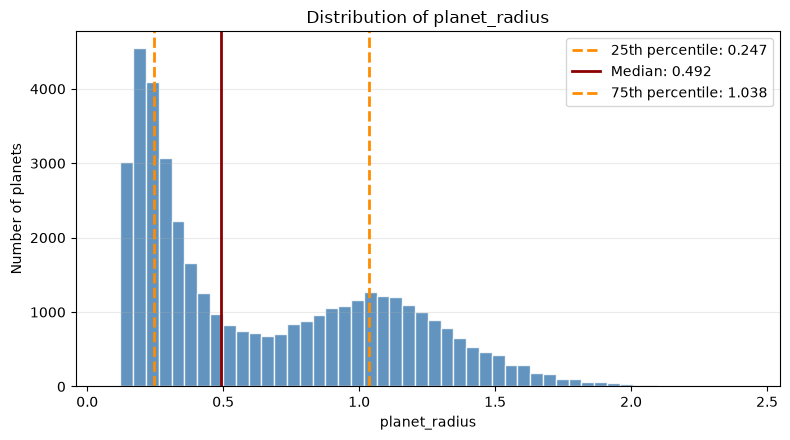

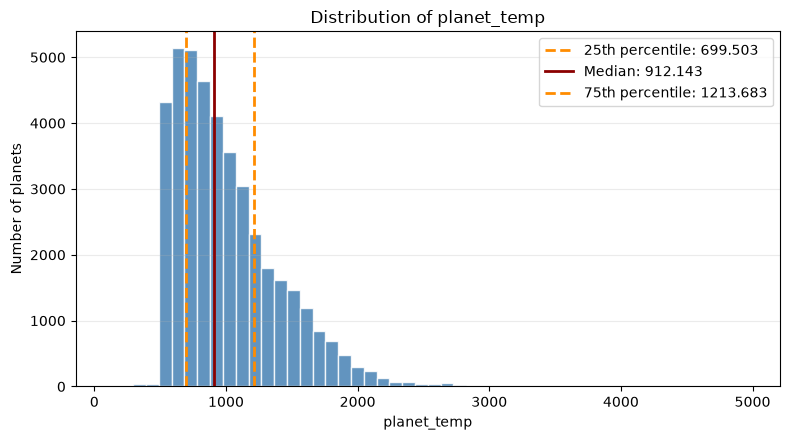

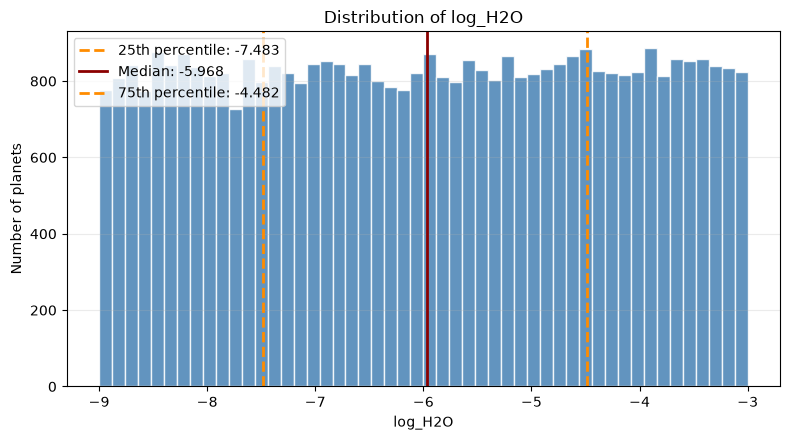

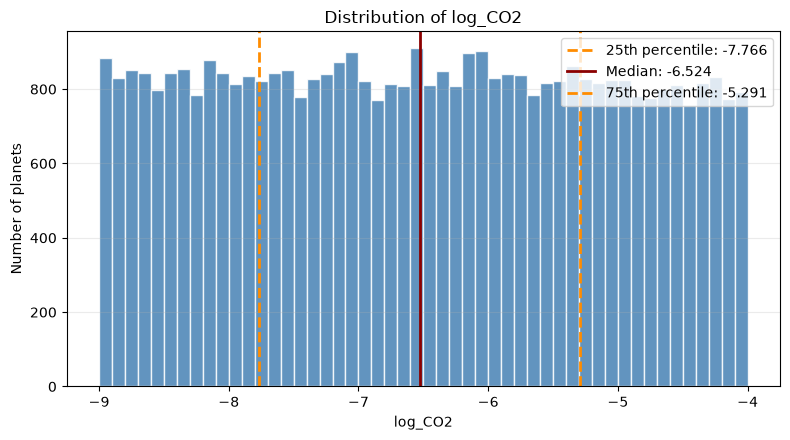

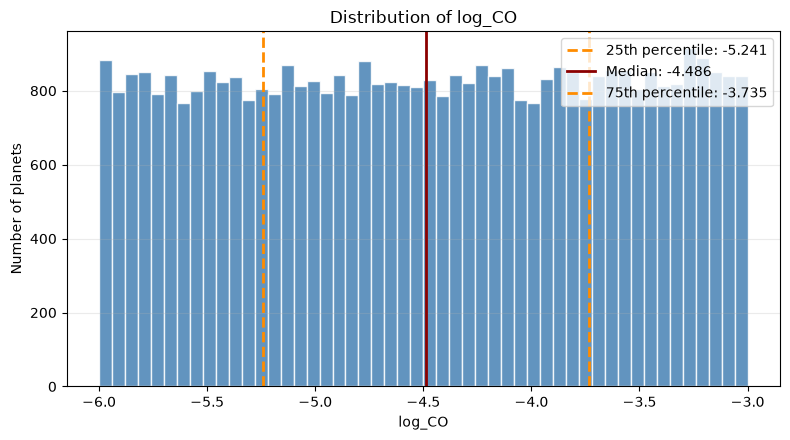

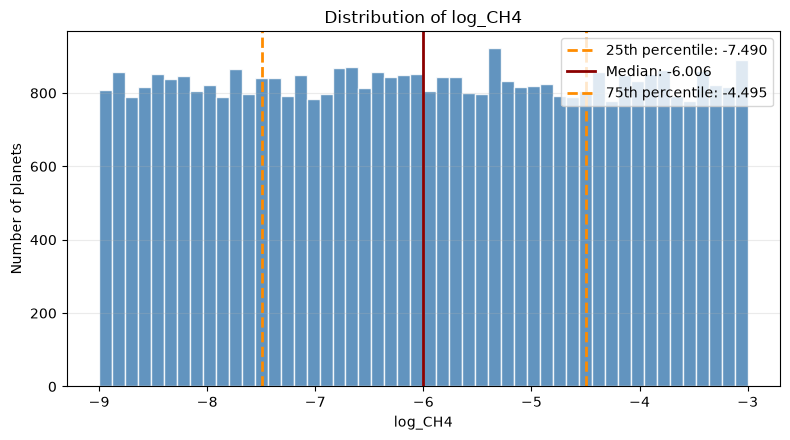

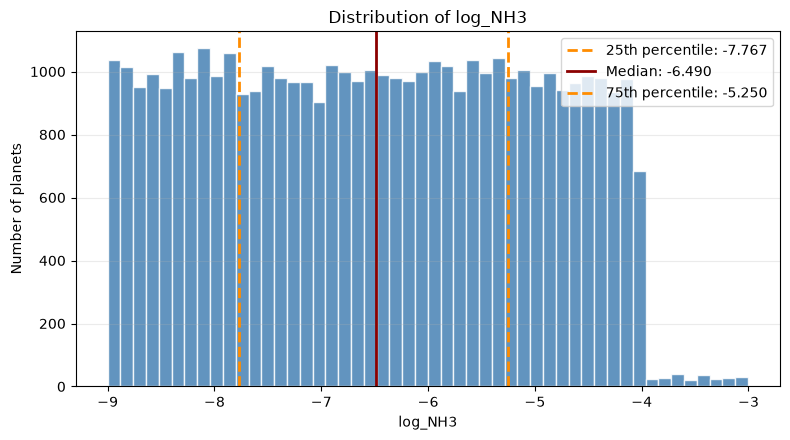

In [19]:
import matplotlib.pyplot as plt

HISTOGRAM_BINS = 50

for target_name in TARGET_COLUMNS:
    target_values = target_only[target_name]

    q25 = target_values.quantile(0.25)
    median = target_values.quantile(0.50)
    q75 = target_values.quantile(0.75)

    fig, ax = plt.subplots(figsize=(8,4.5))

    ax.hist(target_values, bins=HISTOGRAM_BINS, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(q25, color="darkorange", linestyle="--",linewidth=2, label=f"25th percentile: {q25:.3f}")
    ax.axvline(median, color="darkred", linestyle="-", linewidth=2, label=f"Median: {median:.3f}")
    ax.axvline(q75, color="darkorange", linestyle="--", linewidth=2, label=f"75th percentile: {q75:.3f}")

    ax.set_title(f"Distribution of {target_name}")
    ax.set_xlabel(f"{target_name}")
    ax.set_ylabel("Number of planets")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Analysis of plots

`planet_radius`:
- **Multimodal**
- strong cluster of smaller planets around 0.2-0.4.
- second cluster around 0.9-1.3
- thin right tail

Simulated dataset contains more than one planet population?

`planet_temp`:
- most data is in range of 500 - 1500.
- right-skewed.

#### **Molecular abundance targets**

- `log_H20`: unifrom range -9 to -3
- `log_CO2`: uniform range -9 to -4
- `log_CO`: uniform range -6 to -3
- `log_CH4`: uniform range -9 to -3
- `log_NH3`: uniform -9 to -4, sharp drop density -4 to -3.

Marginal coverage might **not** be enough. 90% coverage across all planets could be achieved but perform poorly for very hot planets, large-radius planets, region > -4 for `log_NH3`.

## 2. Observed target-distribution features

The target histograms suggest several points that need to be quantified before
drawing conclusions:

- `planet_radius` appears potentially multimodal;
- `planet_temp` has a strong right-skewed tail;
- `log_H2O`, `log_CO2`, `log_CO` and `log_CH4` appear approximately uniform
  within bounded ranges;
- `log_NH3` shows a sharp reduction in density above approximately `-4`.

These are descriptive observations from the data, **not** physical explanations.
They may reflect some simulator sampling rules/processes, planet population structure or a byproduct of the construction of the dataset. We need to perform some checks to establish
the size and location of these regions.

##### **Target quantiles**

In [20]:
QUANTILE_LEVELS = [
    0.000,
    0.010,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.990,
    0.995,
    1.000,
]

QUANTILE_LABELS = [
    "0%",
    "1%",
    "5%",
    "25%",
    "50%",
    "75%",
    "95%",
    "99%",
    "99.5%",
    "100%",
]

# Keep a copy/snapshot so we can confirm that the EDA does not modify targets
target_snapshot = target_only.copy(deep=True) # Do NOT call a variable 'copy', risks naming issues
target_quantiles = target_only.quantile(QUANTILE_LEVELS).T
target_quantiles.columns = QUANTILE_LABELS
print("Target quantiles:")
display(target_quantiles)

Target quantiles:


,0%,1%,5%,25%,50%,75%,95%,99%,99.5%,100%
planet_radius,0.075000,0.139437,0.159058,0.247160,0.491891,1.037999,1.460436,1.738455,1.852681,2.429861
planet_temp,101.021245,506.832139,542.267737,699.502902,912.143137,1213.682913,1770.516832,2189.800687,2459.179739,4965.288165
log_H2O,-8.999856,-8.933326,-8.691685,-7.482630,-5.968308,-4.482412,-3.299812,-3.061809,-3.031738,-3.000497
log_CO2,-8.999932,-8.953568,-8.758136,-7.766406,-6.524401,-5.291455,-4.259023,-4.052621,-4.026313,-4.000009
log_CO,-5.999984,-5.971193,-5.853478,-5.241152,-4.486111,-3.734558,-3.148324,-3.029170,-3.014652,-3.000010
log_CH4,-8.999856,-8.937492,-8.699810,-7.489864,-6.005781,-4.494879,-3.292086,-3.055172,-3.028334,-3.000333
log_NH3,-8.999985,-8.951560,-8.757598,-7.767215,-6.489616,-5.249536,-4.226713,-4.023059,-3.859367,-3.004636


#### **Temp tail counts**

In [24]:
temperature = target_only["planet_temp"]
total_planets = len(target_only)
temperature_thresholds = [2000, 3000, 4000]

temperature_tail_rows = []

for threshold in temperature_thresholds:
    count = int((temperature > threshold).sum())
    percentage = count / total_planets * 100

    temperature_tail_rows.append({"condition": f"planet_temp >  {threshold}",
                                  "count": count,
                                  "percentage": percentage})

temperature_tail_summary = pd.DataFrame(temperature_tail_rows)
print("Planets in the high temperature tail")
display(temperature_tail_summary)

Planets in the high temperature tail


,condition,count,percentage
0,planet_temp > 2000,867,2.093040
1,planet_temp > 3000,57,0.137605
2,planet_temp > 4000,14,0.033798


#### **Ammonia/NH3 (log) counts**

In [26]:
ammonia = target_only["log_NH3"]

ammonia_region_summary = pd.DataFrame(
    [
        {   "condition": "log_NH3 <= -4",
            "count": int((ammonia <= -4).sum())
         },
         {
            "condition": "log_NH3 > -4",
            "count": int((ammonia > -4).sum()) 
         }
    ]
)

ammonia_region_summary["percentage"] = (ammonia_region_summary["count"] / total_planets *100)
print("Counts of planets on either side of the boundary for log_NH3 = -4")
display(ammonia_region_summary)

Counts of planets on either side of the boundary for log_NH3 = -4


,condition,count,percentage
0,log_NH3 <= -4,41184,99.423026
1,log_NH3 > -4,239,0.576974


#### **Fixed-width bins for NH3**

In [ ]:
AMMONIA_BIN_WIDTH = 0.25

# np.floor and np.ceil align the bin boundaries to multiples of 0.25.
# pd.cut assigns every ammonia value to one interval.

ammonia_lower_edge = (np.floor(ammonia.min() / AMMONIA_BIN_WIDTH) * AMMONIA_BIN_WIDTH)

ammonia_upper_edge = (np.ceil(ammonia.max() / AMMONIA_BIN_WIDTH) * AMMONIA_BIN_WIDTH)

ammonia_bin_edges = np.arange(ammonia_lower_edge, ammonia_upper_edge + AMMONIA_BIN_WIDTH / 2, AMMONIA_BIN_WIDTH)

ammonia_bins = pd.cut(ammonia, bins= ammonia_bin_edges, right=True, include_lowest=True)

ammonia_bin_counts = (ammonia_bins.value_counts(sort=False).rename("count").to_frame())

ammonia_bin_counts["percentage"] = (ammonia_bin_counts["count"] / total_planets *100)

if int(ammonia_bin_counts["count"].sum()) != total_planets:
    raise ValueError("Bins do not contain every planet")

print("Fixed-width log_NH3 bins " f"(width= {AMMONIA_BIN_WIDTH})")
display(ammonia_bin_counts)

Fixed-width log_NH3 bins (width= 0.25)


,count,percentage
log_NH3,,
"(-9.001, -8.75]",2133,5.149313
"(-8.75, -8.5]",2016,4.866861
"(-8.5, -8.25]",2103,5.076890
"(-8.25, -8.0]",2119,5.115516
"(-8.0, -7.75]",2125,5.130000
"(-7.75, -7.5]",1983,4.787196
"(-7.5, -7.25]",2064,4.982739
"(-7.25, -7.0]",1966,4.746156
"(-7.0, -6.75]",2102,5.074476


In [28]:
pd.testing.assert_frame_equal(target_only, target_snapshot, check_exact=True)
print("Target shape:", target_only.shape)
print("Target columns:", target_only.columns.tolist())
print("Target values unchanged.")

Target shape: (41423, 7)
Target columns: ['planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
Target values unchanged.


### **3. Target relationships**

Pairwise correlation coefficients provide nice summaries of target
relationships:

- Pearson correlation measures linear association
- Spearman correlation measures monotonic association using ranked values.

Spearman correlation is useful when a relationship consistently increases or
decreases but is curved rather than linear. It is also generally less sensitive
to extreme values than Pearson correlation. Neither of these coefficients
establish causation, and both can miss more complicated non-monotonic
structure.


We use a hexbin plot to group nearby observations and represent the number of planets in each region using a colour scheme. Three selected relationships are visualised with hexagonal bins.
With 41,423 points an ordinary scatter plot would contain substantial overplotting. We would see dense
regions could become a solid mass and repeated points overlap one another.

#### **Pearson and Spearman matrices**

In [29]:
pearson_correlations = target_only.corr(method="pearson")
spearman_correlations = target_only.corr(method="spearman")

print("Pearson target correlations: ")
display(pearson_correlations.round(3))

print("\nSpearman target correlations: ")
display(spearman_correlations.round(3))

Pearson target correlations: 


,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
planet_radius,1.000,0.081,0.006,0.000,-0.002,0.011,-0.003
planet_temp,0.081,1.000,0.003,0.005,0.005,-0.008,-0.001
log_H2O,0.006,0.003,1.000,0.002,0.002,-0.001,-0.001
log_CO2,0.000,0.005,0.002,1.000,-0.009,-0.004,-0.005
log_CO,-0.002,0.005,0.002,-0.009,1.000,-0.010,0.009
log_CH4,0.011,-0.008,-0.001,-0.004,-0.010,1.000,-0.003
log_NH3,-0.003,-0.001,-0.001,-0.005,0.009,-0.003,1.000



Spearman target correlations: 


,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
planet_radius,1.000,0.068,0.004,-0.000,-0.003,0.010,-0.002
planet_temp,0.068,1.000,0.003,0.005,0.003,-0.006,-0.002
log_H2O,0.004,0.003,1.000,0.002,0.002,-0.001,-0.001
log_CO2,-0.000,0.005,0.002,1.000,-0.009,-0.004,-0.005
log_CO,-0.003,0.003,0.002,-0.009,1.000,-0.010,0.009
log_CH4,0.010,-0.006,-0.001,-0.004,-0.010,1.000,-0.003
log_NH3,-0.002,-0.002,-0.001,-0.005,0.009,-0.003,1.000


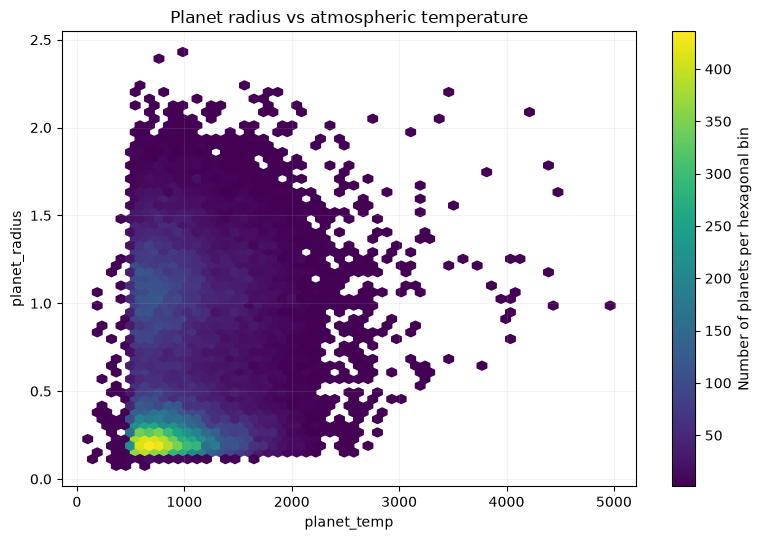

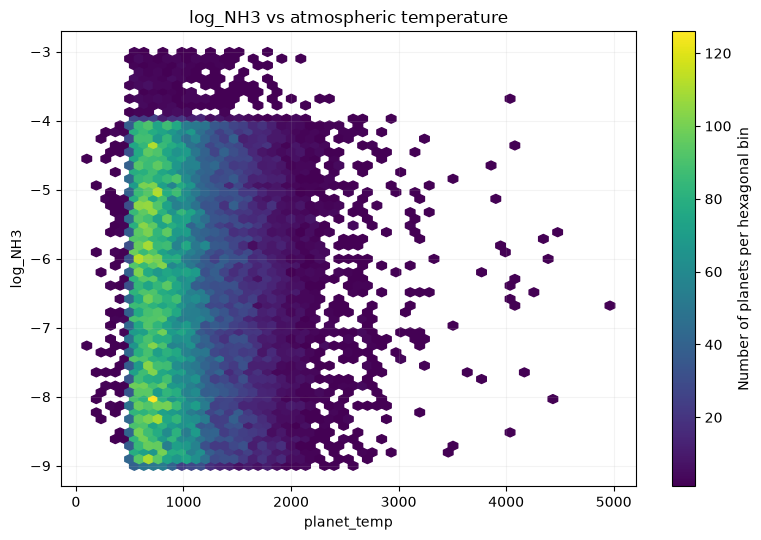

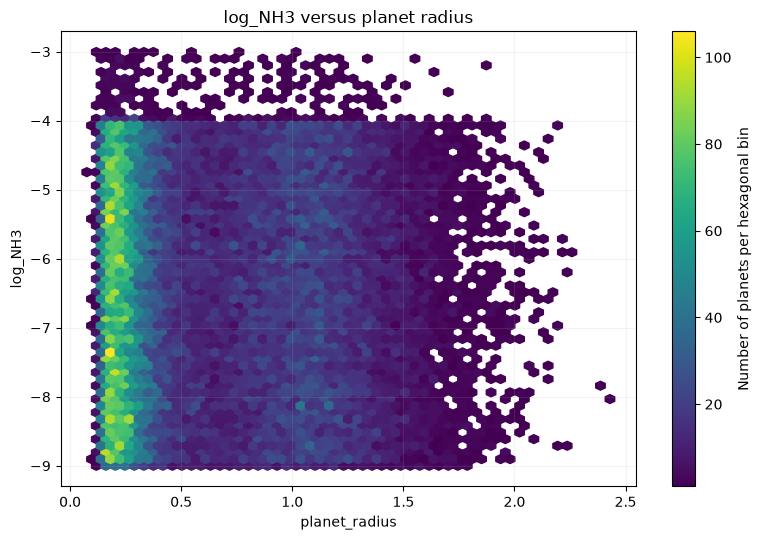

In [33]:
HEXBIN_GRIDSIZE = 55

target_relationships = [
    {"x": "planet_temp",
     "y": "planet_radius",
     "title": "Planet radius vs atmospheric temperature"
     },

     {"x": "planet_temp",
      "y": "log_NH3",
      "title": "log_NH3 vs atmospheric temperature"
      },
      {
        "x": "planet_radius",
        "y": "log_NH3",
        "title": "log_NH3 versus planet radius",
    },
]

for relationship in target_relationships:
    x_name = relationship["x"]
    y_name = relationship["y"]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    hexbin = ax.hexbin(
        target_only[x_name],
        target_only[y_name],
        gridsize=HEXBIN_GRIDSIZE,
        mincnt=1,
        cmap="viridis",
    )

    colour_bar = fig.colorbar(hexbin, ax=ax)
    colour_bar.set_label("Number of planets per hexagonal bin")

    ax.set_title(relationship["title"])
    ax.set_xlabel(f"{x_name}")
    ax.set_ylabel(f"{y_name}")
    ax.grid(alpha=0.15)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

### **Analysis of the radius and temperature distributions**

The `planet_radius` distribution is not unimodal. It contains a strong
concentration of smaller radius planets and a second broad concentration at
larger values. The quartiles reflect this structure: the median is approximately
0.492, whereas the 75th percentile is approximately 1.038. This notebook does
not establish whether these concentrations correspond to distinct physical
planet populations or to the simulator's sampling design, so no physical
interpretation can be determined yet. We will need to discuss this with people who have the domain knowledge or knowledge of the simulator sampling process.

The `planet_temp` distribution is strongly right-skewed. Of the 41,423
labelled planets, 867 (2.093%) have temperatures above 2000, 57 (0.138%) are
above 3000 and only 14 (0.034%) are above 4000. The maximum temperature is
therefore not representative of the bulk of the dataset. Later evaluation
should include a high-temperature subgroup analysis/test, as overall coverage
could hide weak performance in this sparse region.

### **Analysis of the molecular-abundance distributions**

The values for `log_H2O`, `log_CO2`, `log_CO` and `log_CH4` are
approximately uniformly distributed over bounded intervals in logarithmic
space.

The `log_NH3` distribution differs from the other abundance targets. There are
41,042 planets (99.081%) with `log_NH3 <= -4` and only 381 (0.919%) above -4.
Fixed-width bins below -4 contain approximately 2,000 planets each, whereas
bins above -4 contain only around 85–109 planets. This highlights a sharp
reduction in sampling density rather than a 'thinning' tail.

### **Analysis of relationships among targets**

Both the Pearson and Spearman correlation matrices contain values very close
to zero for every pair combination of targets. The largest absolute Spearman coefficient
is only approximately 0.0105. There is therefore no meaningful
global linear or monotonic correlation among the seven simulator parameters.

This could be expected with the targets being sampled independently.
However, almost zero correlation does not imply that their marginal
distributions are simplistic, which we see with `planet_radius` being multimodal, and `planet_temp`
is strongly right-skewed. `log_NH3` contains a small sparse region above -4.

These correlations also do not measure how well spectra or auxiliary metadata
predict each target. They only describe relationships among the simulator parameters

### Implications for conformal evaluation

The target distributions contain rare regions that may be hidden by aggregate
coverage. In particular, approximately 2.1% of the planets have `planet_temp > 2000`, while approximately 0.9% have
`log_NH3 > -4`.

Overall marginal coverage will still be the primary conformal metric, but later
evaluation should also explore descriptive coverage and interval width for
these subgroups when their held-out sample counts are sufficient/large enough. More extreme
temperature thresholds, such as 3000 or 4000, contain too few examples to
support stable standalone coverage estimates after the data are split. **What do we do with this?**